# Latent Autoencoder

Train an autoencoder to learn compressed feature representations of process events.
The latent space can be used for:
- Understanding feature structure
- Clustering similar events
- Visualization (t-SNE/UMAP)
- Anomaly detection

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.interpretability.latent_autoencoder import (
    LatentAutoencoder, AutoencoderTrainer, prepare_dataloader
)

%matplotlib inline

In [2]:
# Load model (to get data categories) and dataset
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

print(f"Dataset size: {len(test_dataset)}")
print(f"\nCategorical features:")
for name, size, _ in model.data_set_categories[0]:
    print(f"  {name}: {size} classes")
print(f"\nNumerical features:")
for name, _, _ in model.data_set_categories[1]:
    print(f"  {name}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## Prepare Data

In [3]:
# Prepare dataloaders
# Split into train/val (80/20)
n_samples = len(test_dataset)
n_train = int(0.8 * n_samples)

indices = torch.randperm(n_samples)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

train_subset = [test_dataset[i] for i in train_indices]
val_subset = [test_dataset[i] for i in val_indices]

train_loader = prepare_dataloader(train_subset, batch_size=128, shuffle=True)
val_loader = prepare_dataloader(val_subset, batch_size=128, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch structure: {len(batch)} tensors")
for i, t in enumerate(batch):
    print(f"  Tensor {i}: shape={t.shape}, dtype={t.dtype}")

Train batches: 295
Val batches: 74

Batch structure: 13 tensors
  Tensor 0: shape=torch.Size([128]), dtype=torch.int64
  Tensor 1: shape=torch.Size([128]), dtype=torch.int64
  Tensor 2: shape=torch.Size([128]), dtype=torch.int64
  Tensor 3: shape=torch.Size([128]), dtype=torch.int64
  Tensor 4: shape=torch.Size([128]), dtype=torch.int64
  Tensor 5: shape=torch.Size([128]), dtype=torch.int64
  Tensor 6: shape=torch.Size([128]), dtype=torch.int64
  Tensor 7: shape=torch.Size([128]), dtype=torch.int64
  Tensor 8: shape=torch.Size([128]), dtype=torch.int64
  Tensor 9: shape=torch.Size([128]), dtype=torch.int64
  Tensor 10: shape=torch.Size([128]), dtype=torch.int64
  Tensor 11: shape=torch.Size([128]), dtype=torch.int64
  Tensor 12: shape=torch.Size([128, 4]), dtype=torch.float32


## Create and Train Autoencoder

In [4]:
# Configuration
LATENT_DIM = 16
HIDDEN_DIMS = [64, 32]
EPOCHS = 100
LEARNING_RATE = 1e-3

# Create autoencoder from model categories
autoencoder = LatentAutoencoder.from_model_categories(
    model.data_set_categories,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=0.1
)

print(f"Autoencoder config:")
print(f"  Latent dim: {autoencoder.config.latent_dim}")
print(f"  Hidden dims: {autoencoder.config.hidden_dims}")
print(f"  Cat vocab sizes: {autoencoder.config.cat_vocab_sizes}")
print(f"  Cat embedding dims: {autoencoder.config.cat_embedding_dims}")
print(f"  Num features: {autoencoder.config.num_features}")

# Count parameters
n_params = sum(p.numel() for p in autoencoder.parameters())
print(f"\nTotal parameters: {n_params:,}")

Autoencoder config:
  Latent dim: 16
  Hidden dims: [64, 32]
  Cat vocab sizes: [16, 24, 175, 3, 361, 23, 9, 6, 6, 6, 8, 6]
  Cat embedding dims: [8, 10, 15, 4, 17, 10, 7, 6, 6, 6, 6, 6]
  Num features: 4

Total parameters: 64,114


In [5]:
# Train
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

trainer = AutoencoderTrainer(autoencoder, learning_rate=LEARNING_RATE, device=device)
history = trainer.train(
    train_loader,
    val_loader,
    epochs=EPOCHS,
    early_stopping_patience=15,
    verbose=True
)

Training on: cpu


Training:   0%|          | 0/100 [00:00<?, ?it/s]

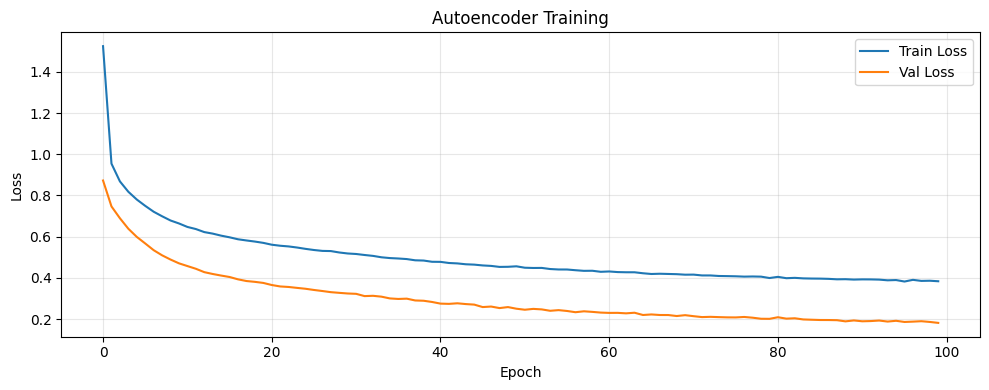

Final train loss: 0.3835
Best val loss: 0.1814


In [6]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
if history['val_loss']:
    ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Autoencoder Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
if history['val_loss']:
    print(f"Best val loss: {min(history['val_loss']):.4f}")

## Extract Latent Representations

In [7]:
# Extract latent representations for all data
full_loader = prepare_dataloader(test_dataset, batch_size=256, shuffle=False)

autoencoder.eval()
all_latents = []
all_activities = []  # First categorical feature (Activity)

with torch.no_grad():
    for batch in full_loader:
        cat_inputs = [t.to(device) for t in batch[:-1]]
        num_inputs = batch[-1].to(device)
        
        latent = autoencoder.encode(cat_inputs, num_inputs)
        all_latents.append(latent.cpu())
        all_activities.append(cat_inputs[0].cpu())  # Activity is first categorical

latents = torch.cat(all_latents, dim=0).numpy()
activities = torch.cat(all_activities, dim=0).numpy()

print(f"Latent representations shape: {latents.shape}")
print(f"Activities shape: {activities.shape}")

Latent representations shape: (47187, 16)
Activities shape: (47187,)


## Visualize Latent Space (t-SNE)

In [9]:
# Get activity names
activity_mapping = {v: k for k, v in model.data_set_categories[0][0][2].items()}

# Subsample for t-SNE (faster)
n_vis = min(5000, len(latents))
vis_indices = np.random.choice(len(latents), n_vis, replace=False)
latents_vis = latents[vis_indices]
activities_vis = activities[vis_indices]

print(f"Running t-SNE on {n_vis} samples...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
latents_2d = tsne.fit_transform(latents_vis)
print("Done!")

Running t-SNE on 5000 samples...
Done!


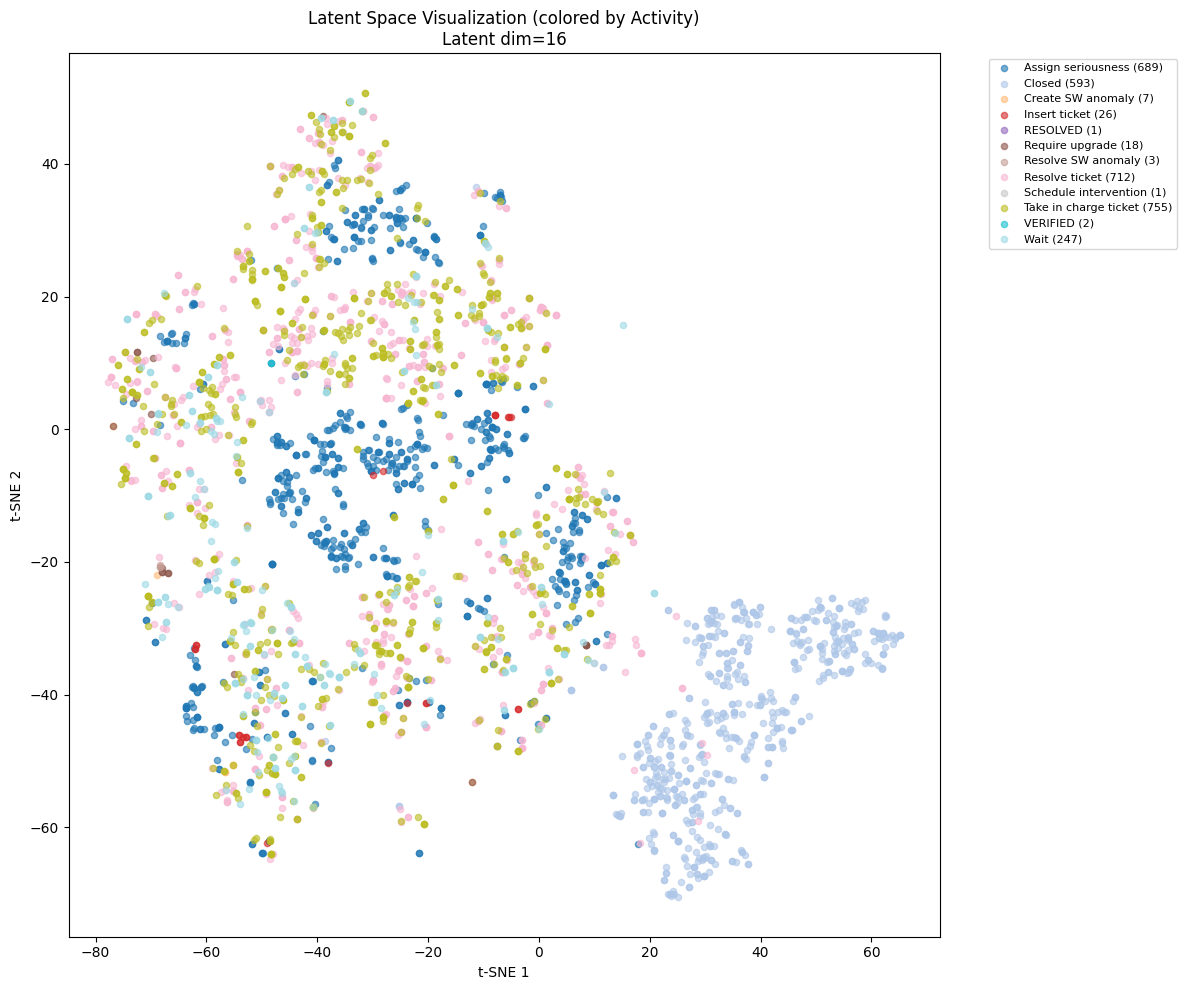

In [10]:
# Plot t-SNE colored by activity
fig, ax = plt.subplots(figsize=(12, 10))

# Get unique activities (excluding padding=0 and EOS)
unique_activities = sorted(set(activities_vis) - {0})
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_activities)))

for i, act_idx in enumerate(unique_activities):
    mask = activities_vis == act_idx
    act_name = activity_mapping.get(act_idx, f'Unknown_{act_idx}')
    if 'EOS' in act_name:
        continue
    ax.scatter(
        latents_2d[mask, 0],
        latents_2d[mask, 1],
        c=[colors[i]],
        label=f'{act_name} ({mask.sum()})',
        alpha=0.6,
        s=20
    )

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Latent Space Visualization (colored by Activity)\nLatent dim={LATENT_DIM}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Reconstruction Quality

In [11]:
# Evaluate reconstruction accuracy
autoencoder.eval()
correct_per_feature = {}
total_per_feature = {}

cat_names = [name for name, _, _ in model.data_set_categories[0]]

for name in cat_names:
    correct_per_feature[name] = 0
    total_per_feature[name] = 0

with torch.no_grad():
    for batch in full_loader:
        cat_inputs = [t.to(device) for t in batch[:-1]]
        num_inputs = batch[-1].to(device)
        
        _, cat_logits, _ = autoencoder(cat_inputs, num_inputs)
        
        for i, (name, target, logits) in enumerate(zip(cat_names, cat_inputs, cat_logits)):
            pred = logits.argmax(dim=-1)
            mask = target != 0  # Ignore padding
            correct_per_feature[name] += (pred[mask] == target[mask]).sum().item()
            total_per_feature[name] += mask.sum().item()

print("Reconstruction Accuracy by Feature:")
print("=" * 50)
for name in cat_names:
    if total_per_feature[name] > 0:
        acc = correct_per_feature[name] / total_per_feature[name]
        print(f"  {name:25s}: {acc:.1%} ({correct_per_feature[name]}/{total_per_feature[name]})")

Reconstruction Accuracy by Feature:
  Activity                 : 95.0% (44845/47187)
  Resource                 : 81.9% (38632/47187)
  Variant index            : 99.1% (26406/26635)
  seriousness              : 100.0% (47187/47187)
  customer                 : 90.7% (41875/46165)
  product                  : 95.9% (45244/47187)
  responsible_section      : 99.7% (47048/47187)
  seriousness_2            : 93.5% (44143/47187)
  service_level            : 99.6% (47004/47187)
  service_type             : 99.7% (47049/47187)
  support_section          : 99.8% (47085/47187)
  workgroup                : 98.3% (46386/47187)


## Latent Space Statistics

Latent Space Statistics:
  Mean: 0.2484
  Std:  1.4132
  Min:  -7.8232
  Max:  10.5581


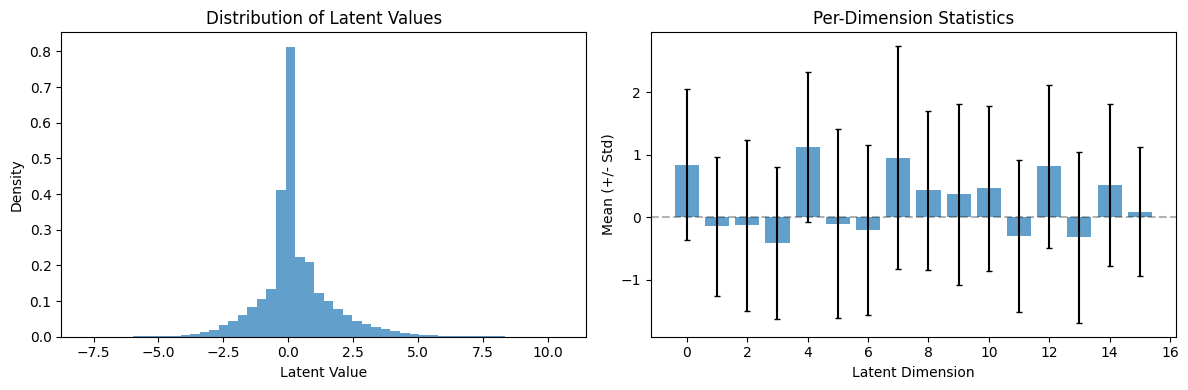

In [12]:
# Analyze latent space statistics
print("Latent Space Statistics:")
print("=" * 50)
print(f"  Mean: {latents.mean():.4f}")
print(f"  Std:  {latents.std():.4f}")
print(f"  Min:  {latents.min():.4f}")
print(f"  Max:  {latents.max():.4f}")

# Per-dimension statistics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of all latent values
axes[0].hist(latents.flatten(), bins=50, density=True, alpha=0.7)
axes[0].set_xlabel('Latent Value')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Latent Values')

# Per-dimension mean and std
dim_means = latents.mean(axis=0)
dim_stds = latents.std(axis=0)
x = np.arange(LATENT_DIM)
axes[1].bar(x, dim_means, yerr=dim_stds, capsize=2, alpha=0.7)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Mean (+/- Std)')
axes[1].set_title('Per-Dimension Statistics')
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Save model
save_path = _current / 'src' / 'interpretability' / 'notebooks' / 'helpdesk' / 'autoencoder_model.pt'
torch.save({
    'config': autoencoder.config,
    'state_dict': autoencoder.state_dict(),
    'history': history
}, save_path)
print(f"Model saved to: {save_path}")

Model saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/helpdesk/autoencoder_model.pt
